In [1]:
# Experiment 1: FIND-S Algorithm
# Aim: Implement and demonstrate the FIND-S algorithm
#      for finding the most specific hypothesis.

# Training dataset
# Attributes: Sky, AirTemp, Humidity, Wind, Water, Forecast
# Target: EnjoySport

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High',    'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High',    'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High',    'Strong', 'Cool', 'Change', 'Yes']
]

# Initialize the most specific hypothesis
hypothesis = ['0', '0', '0', '0', '0', '0']

print("Training Examples:")
for row in data:
    print(row)

print("\nFIND-S Algorithm Steps:\n")

# FIND-S algorithm
for i, example in enumerate(data):
    attributes = example[:-1]
    target = example[-1]

    # Consider only positive examples
    if target == 'Yes':

        # First positive example
        if hypothesis == ['0', '0', '0', '0', '0', '0']:
            hypothesis = attributes.copy()

        # Generalize hypothesis when necessary
        else:
            for j in range(len(hypothesis)):
                if hypothesis[j] != attributes[j]:
                    hypothesis[j] = '?'

    print(f"After training example {i + 1}: {hypothesis}")

# Final hypothesis
print("\nMost Specific Hypothesis:")
print(hypothesis)

Training Examples:
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes']
['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes']
['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No']
['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']

FIND-S Algorithm Steps:

After training example 1: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
After training example 2: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
After training example 3: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
After training example 4: ['Sunny', 'Warm', '?', 'Strong', '?', '?']

Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [3]:
# Experiment 2: Candidate-Elimination Algorithm
# Aim: Implement and demonstrate the Candidate-Elimination algorithm
#      using training examples stored in a CSV file.

import pandas as pd

# ---------------------------------------------------------
# STEP 1: Create the training dataset and save it as CSV
# ---------------------------------------------------------

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Save dataset as CSV
csv_file = 'training_data.csv'
df.to_csv(csv_file, index=False)

print("Training data:")
print(df)


# ---------------------------------------------------------
# STEP 2: Read the CSV file
# ---------------------------------------------------------

data = pd.read_csv(csv_file)

attributes = list(data.columns[:-1])
target = data.columns[-1]

X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values


# ---------------------------------------------------------
# STEP 3: Initialize Specific (S) and General (G)
# ---------------------------------------------------------

# Most specific hypothesis
S = ['0'] * len(attributes)

# Most general hypothesis
G = [['?'] * len(attributes)]


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def covers(hypothesis, example):
    """Check whether a hypothesis covers an example."""
    for h, x in zip(hypothesis, example):
        if h != '?' and h != x:
            return False
    return True


def more_general(h1, h2):
    """Return True if h1 is more general than h2."""
    for a, b in zip(h1, h2):
        if a != '?' and a != b:
            return False
    return True


# ---------------------------------------------------------
# STEP 4: Candidate-Elimination Algorithm
# ---------------------------------------------------------

for i in range(len(X)):

    example = X[i]
    label = Y[i]

    print(f"\nExample {i + 1}: {list(example)} -> {label}")

    if label == 'Yes':

        # Remove hypotheses from G that do not cover positive example
        G = [g for g in G if covers(g, example)]

        # Generalize S
        for j in range(len(attributes)):

            if S[j] == '0':
                S[j] = example[j]

            elif S[j] != example[j]:
                S[j] = '?'

        # Remove G hypotheses that are not more general than S
        G = [g for g in G if more_general(g, S)]

    else:

        # Remove hypotheses from S that cover negative example
        if covers(S, example):
            # Generate specializations of S
            new_G = []

            for g in G:
                for j in range(len(attributes)):
                    if g[j] == '?' and S[j] != example[j]:
                        new_h = g.copy()
                        new_h[j] = S[j]
                        new_G.append(new_h)

            G = new_G

    print("Specific Boundary (S):", S)
    print("General Boundary (G):", G)


# ---------------------------------------------------------
# STEP 5: Display final version space boundaries
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL RESULT")
print("=" * 50)

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")
for g in G:
    print(g)

print("\nThe set of hypotheses consistent with the training examples")
print("lies between the Specific Boundary (S) and General Boundary (G).")

Training data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Example 1: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same'] -> Yes
Specific Boundary (S): ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
General Boundary (G): [['?', '?', '?', '?', '?', '?']]

Example 2: ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same'] -> Yes
Specific Boundary (S): ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General Boundary (G): [['?', '?', '?', '?', '?', '?']]

Example 3: ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change'] -> No
Specific Boundary (S): ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
General Boundary (G): [['?', '?', '?', '?', '?', '?']]

Example 4: ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change'] -> Yes
Specific B

In [4]:
# Experiment 3: Decision Tree using ID3 Algorithm
# Aim: Demonstrate the working of the ID3 algorithm
#      and classify a new sample.

import pandas as pd
import math

# ---------------------------------------------------------
# STEP 1: Create the dataset
# ---------------------------------------------------------

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain',
                'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast',
                'Overcast', 'Rain'],

    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild',
                    'Hot', 'Mild'],

    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High',
                 'Normal', 'High'],

    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Strong'],

    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
                   'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
                   'Yes', 'No']
}

df = pd.DataFrame(data)

print("Training Dataset:\n")
print(df)


# ---------------------------------------------------------
# STEP 2: Calculate Entropy
# ---------------------------------------------------------

def entropy(data):
    values = data.value_counts()

    total = len(data)
    ent = 0

    for count in values:
        probability = count / total
        ent -= probability * math.log2(probability)

    return ent


# ---------------------------------------------------------
# STEP 3: Calculate Information Gain
# ---------------------------------------------------------

def information_gain(df, attribute, target):
    total_entropy = entropy(df[target])

    values = df[attribute].unique()
    weighted_entropy = 0

    for value in values:
        subset = df[df[attribute] == value]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])

    return total_entropy - weighted_entropy


# ---------------------------------------------------------
# STEP 4: Display Information Gain
# ---------------------------------------------------------

print("\nEntropy of complete dataset:",
      round(entropy(df['PlayTennis']), 4))

print("\nInformation Gain for each attribute:")

attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']

for attribute in attributes:
    gain = information_gain(df, attribute, 'PlayTennis')
    print(attribute, "=", round(gain, 4))


# ---------------------------------------------------------
# STEP 5: Implement ID3 Algorithm
# ---------------------------------------------------------

def ID3(df, target, attributes):

    # If all examples belong to the same class
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return df[target].mode()[0]

    # Select attribute with maximum Information Gain
    gains = {
        attribute: information_gain(df, attribute, target)
        for attribute in attributes
    }

    best_attribute = max(gains, key=gains.get)

    tree = {best_attribute: {}}

    # Create branches
    for value in df[best_attribute].unique():

        subset = df[df[best_attribute] == value]

        remaining_attributes = [
            attribute for attribute in attributes
            if attribute != best_attribute
        ]

        tree[best_attribute][value] = ID3(
            subset,
            target,
            remaining_attributes
        )

    return tree


# ---------------------------------------------------------
# STEP 6: Build the Decision Tree
# ---------------------------------------------------------

tree = ID3(
    df,
    'PlayTennis',
    ['Outlook', 'Temperature', 'Humidity', 'Wind']
)

print("\nDecision Tree:")
print(tree)


# ---------------------------------------------------------
# STEP 7: Function to classify a new sample
# ---------------------------------------------------------

def classify(tree, sample):

    if not isinstance(tree, dict):
        return tree

    attribute = next(iter(tree))

    value = sample[attribute]

    if value in tree[attribute]:
        return classify(tree[attribute][value], sample)

    return "Unknown"


# ---------------------------------------------------------
# STEP 8: Classify a New Sample
# ---------------------------------------------------------

new_sample = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

prediction = classify(tree, new_sample)

print("\nNew Sample:")
print(new_sample)

print("\nClassification Result:")
print("Play Tennis =", prediction)

Training Dataset:

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

Entropy of complete dataset: 0.9403

Information Gain for each attribute:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Wind = 0.0481

Decision Tree:
{'Outlook': {'Sunny': {'H

In [5]:
# Experiment 4: Artificial Neural Network using Backpropagation
# Aim: Build an Artificial Neural Network using the
#      Backpropagation algorithm and test it using the XOR dataset.

import numpy as np

# ---------------------------------------------------------
# STEP 1: Create the XOR dataset
# ---------------------------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

Y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Training Dataset:")
print("Input\t\tTarget")

for i in range(len(X)):
    print(X[i], "\t", Y[i][0])


# ---------------------------------------------------------
# STEP 2: Define activation function
# ---------------------------------------------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


# ---------------------------------------------------------
# STEP 3: Initialize weights and biases
# ---------------------------------------------------------

np.random.seed(42)

# Network structure:
# 2 input neurons
# 4 hidden neurons
# 1 output neuron

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Weights
W1 = np.random.uniform(-1, 1, (input_neurons, hidden_neurons))
W2 = np.random.uniform(-1, 1, (hidden_neurons, output_neurons))

# Biases
b1 = np.zeros((1, hidden_neurons))
b2 = np.zeros((1, output_neurons))

# Learning rate
learning_rate = 0.5

# Number of training iterations
epochs = 10000


# ---------------------------------------------------------
# STEP 4: Backpropagation training
# ---------------------------------------------------------

for epoch in range(epochs):

    # -------------------------
    # Forward Propagation
    # -------------------------

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    output_input = np.dot(hidden_output, W2) + b2
    output = sigmoid(output_input)

    # -------------------------
    # Calculate Error
    # -------------------------

    error = Y - output

    # -------------------------
    # Backpropagation
    # -------------------------

    output_delta = error * sigmoid_derivative(output)

    hidden_error = np.dot(output_delta, W2.T)

    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)

    # -------------------------
    # Update weights and biases
    # -------------------------

    W2 += np.dot(hidden_output.T, output_delta) * learning_rate
    b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate

    W1 += np.dot(X.T, hidden_delta) * learning_rate
    b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate


# ---------------------------------------------------------
# STEP 5: Test the trained neural network
# ---------------------------------------------------------

hidden_output = sigmoid(np.dot(X, W1) + b1)
predicted_output = sigmoid(np.dot(hidden_output, W2) + b2)

print("\n" + "=" * 50)
print("TESTING THE TRAINED NEURAL NETWORK")
print("=" * 50)

print("\nInput\t\tTarget\tPredicted Output\tClass")

for i in range(len(X)):

    probability = predicted_output[i][0]

    if probability >= 0.5:
        predicted_class = 1
    else:
        predicted_class = 0

    print(
        X[i],
        "\t",
        int(Y[i][0]),
        "\t",
        round(probability, 4),
        "\t\t",
        predicted_class
    )


# ---------------------------------------------------------
# STEP 6: Calculate accuracy
# ---------------------------------------------------------

predicted_classes = (predicted_output >= 0.5).astype(int)

accuracy = np.mean(predicted_classes == Y) * 100

print("\nAccuracy:", round(accuracy, 2), "%")

Training Dataset:
Input		Target
[0. 0.] 	 0.0
[0. 1.] 	 1.0
[1. 0.] 	 1.0
[1. 1.] 	 0.0

TESTING THE TRAINED NEURAL NETWORK

Input		Target	Predicted Output	Class
[0. 0.] 	 0 	 0.0095 		 0
[0. 1.] 	 1 	 0.9839 		 1
[1. 0.] 	 1 	 0.9849 		 1
[1. 1.] 	 0 	 0.0195 		 0

Accuracy: 100.0 %


In [6]:
# Experiment 5: Implementation of K-Nearest Neighbours (K-NN)
# Aim: Implement K-Nearest Neighbours algorithm in Python
#      and classify samples using the Iris dataset.

# Import required libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Iris Dataset")
print("------------")

print("Features:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nFirst 5 samples:")
print(X[:5])


# ---------------------------------------------------------
# STEP 2: Split the dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nNumber of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Create the K-NN classifier
# ---------------------------------------------------------

# K = 5
k = 5

knn = KNeighborsClassifier(n_neighbors=k)


# ---------------------------------------------------------
# STEP 4: Train the K-NN model
# ---------------------------------------------------------

knn.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 5: Predict the test samples
# ---------------------------------------------------------

y_pred = knn.predict(X_test)


# ---------------------------------------------------------
# STEP 6: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("K-NEAREST NEIGHBOURS RESULTS")
print("=" * 50)

print("\nK value:", k)

print("Accuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 7: Display actual and predicted values
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 8: Classification report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# ---------------------------------------------------------
# STEP 9: Classify a new sample
# ---------------------------------------------------------

new_sample = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

prediction = knn.predict(new_sample)

print("\nNew Sample:")
print(new_sample)

print("\nPredicted Class:")
print(iris.target_names[prediction[0]])

Iris Dataset
------------
Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Number of training samples: 120
Number of testing samples: 30

K-NEAREST NEIGHBOURS RESULTS

K value: 5
Accuracy: 100.0 %

Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: 

Iris Dataset
------------
Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Number of samples: 150

Training samples: 120
Testing samples: 30

NAÏVE BAYES RESULTS

Accuracy: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


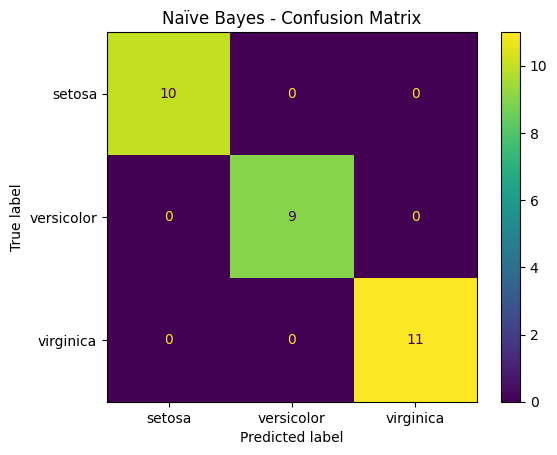


Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: virginica 	Predicted: virginica
Actual: 

In [7]:
# Experiment 6: Naïve Bayes Algorithm
# Aim: Implement Naïve Bayes algorithm in Python
#      and display the results using confusion matrix and accuracy.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Iris Dataset")
print("------------")

print("Features:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nNumber of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Create Naïve Bayes classifier
# ---------------------------------------------------------

model = GaussianNB()


# ---------------------------------------------------------
# STEP 4: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 5: Predict the test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 6: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("NAÏVE BAYES RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 7: Generate confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 8: Display confusion matrix graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Naïve Bayes - Confusion Matrix")
plt.show()


# ---------------------------------------------------------
# STEP 9: Display actual and predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )

Iris Dataset
------------
Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes used:
0 - Setosa
1 - Versicolor

Number of samples: 100

Training samples: 80
Testing samples: 20

LOGISTIC REGRESSION RESULTS

Accuracy: 100.0 %

Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: s

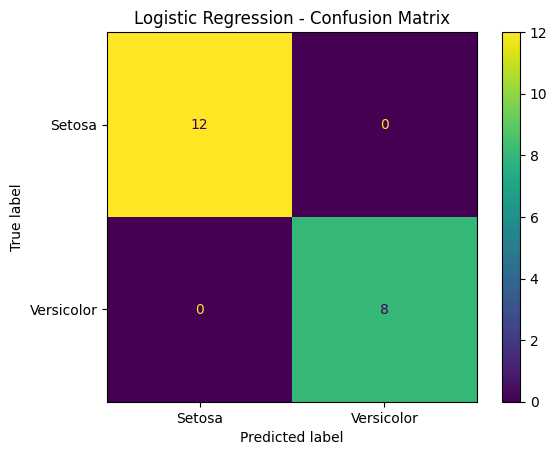


New Sample:
[[5.1 3.5 1.4 0.2]]

Predicted Class:
setosa


In [8]:
# Experiment 7: Logistic Regression (LR)
# Aim: Implement Logistic Regression algorithm in Python
#      and classify samples using the Iris dataset.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

# Use only Setosa and Versicolor
X = iris.data[:100]
y = iris.target[:100]

print("Iris Dataset")
print("------------")

print("Features:")
print(iris.feature_names)

print("\nClasses used:")
print("0 - Setosa")
print("1 - Versicolor")

print("\nNumber of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Create Logistic Regression model
# ---------------------------------------------------------

model = LogisticRegression()


# ---------------------------------------------------------
# STEP 4: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 5: Predict the test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 6: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 7: Display actual and predicted values
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):

    actual_name = iris.target_names[actual]
    predicted_name = iris.target_names[predicted]

    print(
        "Actual:",
        actual_name,
        "\tPredicted:",
        predicted_name
    )


# ---------------------------------------------------------
# STEP 8: Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 9: Display confusion matrix graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Setosa', 'Versicolor']
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# ---------------------------------------------------------
# STEP 10: Test a new sample
# ---------------------------------------------------------

new_sample = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

prediction = model.predict(new_sample)

print("\nNew Sample:")
print(new_sample)

print("\nPredicted Class:")
print(iris.target_names[prediction[0]])

Training Dataset:

Hours Studied	Marks
1 		 35
2 		 40
3 		 45
4 		 50
5 		 55
6 		 60
7 		 65
8 		 70
9 		 75
10 		 80

Training samples: 8
Testing samples: 2

LINEAR REGRESSION RESULTS

Slope (Coefficient): 5.0
Intercept: 30.0

Regression Equation:
Marks = 30.0 + 5.0 × Hours

Actual vs Predicted:
Actual: 75 	Predicted: 75.0
Actual: 40 	Predicted: 40.0

Mean Squared Error (MSE): 0.0
R² Score: 1.0

New Sample:
Hours Studied: 7
Predicted Marks: 65.0


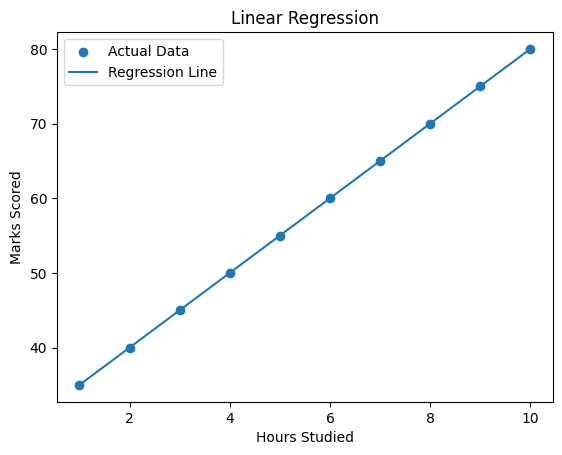

In [9]:
# Experiment 8: Linear Regression
# Aim: Implement Linear Regression algorithm in Python
#      to predict marks based on hours studied.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create the dataset
# ---------------------------------------------------------

# Hours studied
X = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]).reshape(-1, 1)

# Marks scored
y = np.array([
    35, 40, 45, 50, 55,
    60, 65, 70, 75, 80
])

print("Training Dataset:")
print("\nHours Studied\tMarks")

for hours, marks in zip(X.flatten(), y):
    print(hours, "\t\t", marks)


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Create Linear Regression model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 4: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 5: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 6: Display model parameters
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)

print("\nSlope (Coefficient):", round(model.coef_[0], 2))
print("Intercept:", round(model.intercept_, 2))

print(
    "\nRegression Equation:"
)
print(
    "Marks =",
    round(model.intercept_, 2),
    "+",
    round(model.coef_[0], 2),
    "× Hours"
)


# ---------------------------------------------------------
# STEP 7: Display actual vs predicted values
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual:",
        actual,
        "\tPredicted:",
        round(predicted, 2)
    )


# ---------------------------------------------------------
# STEP 8: Calculate performance
# ---------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 4))


# ---------------------------------------------------------
# STEP 9: Predict marks for a new sample
# ---------------------------------------------------------

hours = np.array([[7]])

predicted_marks = model.predict(hours)

print("\nNew Sample:")
print("Hours Studied:", hours[0][0])

print(
    "Predicted Marks:",
    round(predicted_marks[0], 2)
)


# ---------------------------------------------------------
# STEP 10: Plot the regression line
# ---------------------------------------------------------

plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Marks Scored")
plt.title("Linear Regression")
plt.legend()
plt.show()

Dataset:

X	Y
1 	 2
2 	 4
3 	 7
4 	 11
5 	 16
6 	 22
7 	 29
8 	 37
9 	 46
10 	 56

COMPARISON OF LINEAR AND POLYNOMIAL REGRESSION

LINEAR REGRESSION
-----------------
Slope: 6.0
Intercept: -10.0
MSE: 13.2
R² Score: 0.9574

POLYNOMIAL REGRESSION
---------------------
Polynomial Degree: 2
Coefficients: [6.]
MSE: 0.0
R² Score: 1.0

MODEL COMPARISON

Linear Regression MSE: 13.2
Polynomial Regression MSE: 0.0

Linear Regression R²: 0.9574
Polynomial Regression R²: 1.0

Result:
Polynomial Regression fits the dataset better.


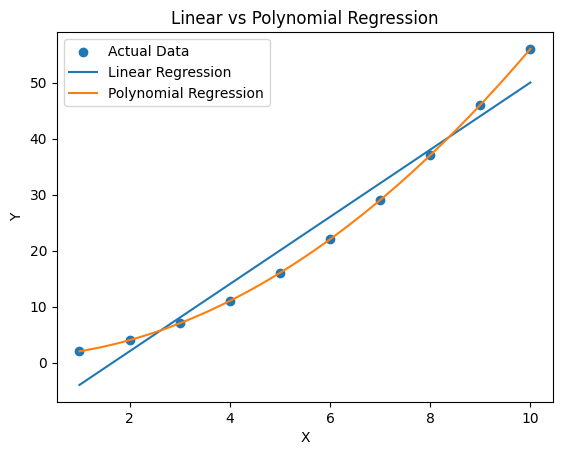

In [10]:
# Experiment 9: Comparison of Linear and Polynomial Regression
# Aim: Compare Linear Regression and Polynomial Regression
#      using Python.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create a basic dataset
# ---------------------------------------------------------

X = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
]).reshape(-1, 1)

# Non-linear relationship
y = np.array([
    2, 4, 7, 11, 16,
    22, 29, 37, 46, 56
])

print("Dataset:")
print("\nX\tY")

for x, value in zip(X.flatten(), y):
    print(x, "\t", value)


# ---------------------------------------------------------
# STEP 2: Linear Regression
# ---------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(X, y)

linear_prediction = linear_model.predict(X)

linear_mse = mean_squared_error(y, linear_prediction)
linear_r2 = r2_score(y, linear_prediction)


# ---------------------------------------------------------
# STEP 3: Polynomial Regression
# ---------------------------------------------------------

# Degree of polynomial
degree = 2

poly = PolynomialFeatures(degree=degree)

X_poly = poly.fit_transform(X)

polynomial_model = LinearRegression()

polynomial_model.fit(X_poly, y)

polynomial_prediction = polynomial_model.predict(X_poly)

polynomial_mse = mean_squared_error(y, polynomial_prediction)
polynomial_r2 = r2_score(y, polynomial_prediction)


# ---------------------------------------------------------
# STEP 4: Display results
# ---------------------------------------------------------

print("\n" + "=" * 55)
print("COMPARISON OF LINEAR AND POLYNOMIAL REGRESSION")
print("=" * 55)

print("\nLINEAR REGRESSION")
print("-----------------")

print("Slope:", round(linear_model.coef_[0], 4))
print("Intercept:", round(linear_model.intercept_, 4))
print("MSE:", round(linear_mse, 4))
print("R² Score:", round(linear_r2, 4))


print("\nPOLYNOMIAL REGRESSION")
print("---------------------")

print("Polynomial Degree:", degree)
print("Coefficients:", linear_model.coef_)

print("MSE:", round(polynomial_mse, 4))
print("R² Score:", round(polynomial_r2, 4))


# ---------------------------------------------------------
# STEP 5: Compare the models
# ---------------------------------------------------------

print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)

print("\nLinear Regression MSE:",
      round(linear_mse, 4))

print("Polynomial Regression MSE:",
      round(polynomial_mse, 4))

print("\nLinear Regression R²:",
      round(linear_r2, 4))

print("Polynomial Regression R²:",
      round(polynomial_r2, 4))


if polynomial_r2 > linear_r2:
    print("\nResult:")
    print("Polynomial Regression fits the dataset better.")
else:
    print("\nResult:")
    print("Linear Regression fits the dataset better.")


# ---------------------------------------------------------
# STEP 6: Plot both regression models
# ---------------------------------------------------------

X_plot = np.linspace(1, 10, 100).reshape(-1, 1)

# Linear prediction
y_linear_plot = linear_model.predict(X_plot)

# Polynomial prediction
X_plot_poly = poly.transform(X_plot)
y_poly_plot = polynomial_model.predict(X_plot_poly)


plt.scatter(X, y, label="Actual Data")

plt.plot(
    X_plot,
    y_linear_plot,
    label="Linear Regression"
)

plt.plot(
    X_plot,
    y_poly_plot,
    label="Polynomial Regression"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")

plt.legend()
plt.show()

Dataset:
[1.  1.2 1.5 1.8 2.  7.  7.2 7.5 7.8 8. ]

EXPECTATION-MAXIMIZATION RESULTS

Data Point	Cluster
1.0 		Cluster 1
1.2 		Cluster 1
1.5 		Cluster 1
1.8 		Cluster 1
2.0 		Cluster 1
7.0 		Cluster 2
7.2 		Cluster 2
7.5 		Cluster 2
7.8 		Cluster 2
8.0 		Cluster 2

Gaussian Means:
[1.5 7.5]

Gaussian Variances:
[0.136001 0.136001]

Mixing Weights:
[0.5 0.5]

Log-Likelihood:
-1.1145

Cluster Probabilities:
Data: 1.0 -> [1. 0.]
Data: 1.2 -> [1. 0.]
Data: 1.5 -> [1. 0.]
Data: 1.8 -> [1. 0.]
Data: 2.0 -> [1. 0.]
Data: 7.0 -> [0. 1.]
Data: 7.2 -> [0. 1.]
Data: 7.5 -> [0. 1.]
Data: 7.8 -> [0. 1.]
Data: 8.0 -> [0. 1.]


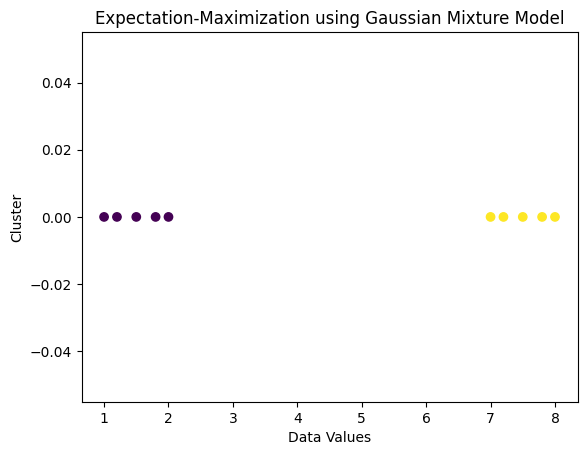

In [11]:
# Experiment 10: Expectation-Maximization (EM) Algorithm
# Aim: Implement the Expectation-Maximization algorithm
#      using a Gaussian Mixture Model.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture


# ---------------------------------------------------------
# STEP 1: Create a simple dataset
# ---------------------------------------------------------

X = np.array([
    1.0, 1.2, 1.5, 1.8, 2.0,
    7.0, 7.2, 7.5, 7.8, 8.0
]).reshape(-1, 1)

print("Dataset:")
print(X.flatten())


# ---------------------------------------------------------
# STEP 2: Create the Gaussian Mixture Model
# ---------------------------------------------------------

# Number of Gaussian clusters
n_components = 2

gmm = GaussianMixture(
    n_components=n_components,
    random_state=42
)


# ---------------------------------------------------------
# STEP 3: Train the model using EM algorithm
# ---------------------------------------------------------

gmm.fit(X)


# ---------------------------------------------------------
# STEP 4: Predict cluster for each data point
# ---------------------------------------------------------

labels = gmm.predict(X)


# ---------------------------------------------------------
# STEP 5: Display the results
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("EXPECTATION-MAXIMIZATION RESULTS")
print("=" * 50)

print("\nData Point\tCluster")

for value, label in zip(X.flatten(), labels):
    print(
        round(value, 2),
        "\t\tCluster",
        label + 1
    )


# ---------------------------------------------------------
# STEP 6: Display Gaussian parameters
# ---------------------------------------------------------

print("\nGaussian Means:")
print(gmm.means_.flatten())

print("\nGaussian Variances:")
print(gmm.covariances_.flatten())

print("\nMixing Weights:")
print(gmm.weights_)


# ---------------------------------------------------------
# STEP 7: Display log likelihood
# ---------------------------------------------------------

print("\nLog-Likelihood:")
print(round(gmm.lower_bound_, 4))


# ---------------------------------------------------------
# STEP 8: Display cluster probabilities
# ---------------------------------------------------------

probabilities = gmm.predict_proba(X)

print("\nCluster Probabilities:")

for i, value in enumerate(X.flatten()):
    print(
        "Data:",
        round(value, 2),
        "->",
        np.round(probabilities[i], 4)
    )


# ---------------------------------------------------------
# STEP 9: Plot the clusters
# ---------------------------------------------------------

plt.scatter(
    X.flatten(),
    np.zeros(len(X)),
    c=labels
)

plt.xlabel("Data Values")
plt.ylabel("Cluster")
plt.title("Expectation-Maximization using Gaussian Mixture Model")
plt.show()

Credit Score Dataset:
    Income  LoanAmount  CreditHistory  CreditScore Class
0    25000       50000              1          300  Poor
1    30000       55000              1          320  Poor
2    35000       60000              1          350  Poor
3    40000       65000              1          380  Poor
4    45000       70000              1          400  Poor
5    50000       60000              1          450  Poor
6    55000       65000              1          480  Poor
7    60000       70000              1          500  Poor
8    65000       75000              1          550  Good
9    70000       70000              1          580  Good
10   75000       65000              1          620  Good
11   80000       60000              1          650  Good
12   85000       55000              1          680  Good
13   90000       50000              1          720  Good
14   95000       45000              1          750  Good
15  100000       40000              1          780  Good
16   2800

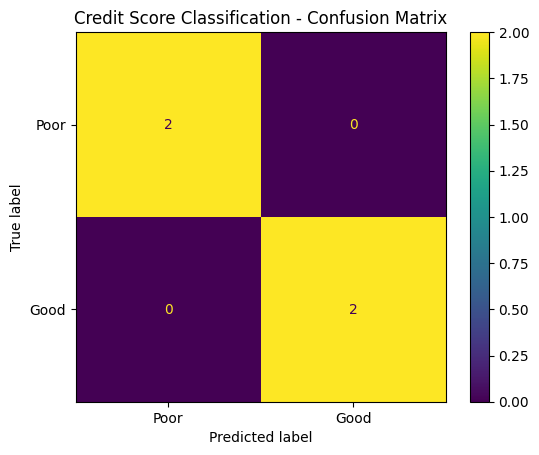


New Customer Details:
Income: ₹75,000
Loan Amount: ₹60,000
Credit History: Good
Credit Score: 680

Predicted Credit Classification:
Good Credit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [12]:
# Experiment 11: Credit Score Classification
# Aim: Implement a machine learning model for
#      Credit Score Classification.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Create a basic credit score dataset
# ---------------------------------------------------------

data = {
    'Income': [
        25000, 30000, 35000, 40000, 45000,
        50000, 55000, 60000, 65000, 70000,
        75000, 80000, 85000, 90000, 95000,
        100000, 28000, 32000, 42000, 58000
    ],

    'LoanAmount': [
        50000, 55000, 60000, 65000, 70000,
        60000, 65000, 70000, 75000, 70000,
        65000, 60000, 55000, 50000, 45000,
        40000, 60000, 70000, 80000, 65000
    ],

    'CreditHistory': [
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 0, 0, 0, 1
    ],

    'CreditScore': [
        300, 320, 350, 380, 400,
        450, 480, 500, 550, 580,
        620, 650, 680, 720, 750,
        780, 310, 330, 370, 520
    ],

    'Class': [
        'Poor', 'Poor', 'Poor', 'Poor', 'Poor',
        'Poor', 'Poor', 'Poor', 'Good', 'Good',
        'Good', 'Good', 'Good', 'Good', 'Good',
        'Good', 'Poor', 'Poor', 'Poor', 'Good'
    ]
}

df = pd.DataFrame(data)

print("Credit Score Dataset:")
print(df)


# ---------------------------------------------------------
# STEP 2: Convert target classes into numerical values
# ---------------------------------------------------------

df['Class'] = df['Class'].map({
    'Poor': 0,
    'Good': 1
})


# ---------------------------------------------------------
# STEP 3: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Income', 'LoanAmount', 'CreditHistory', 'CreditScore']
]

y = df['Class']


# ---------------------------------------------------------
# STEP 4: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 5: Create Logistic Regression model
# ---------------------------------------------------------

model = LogisticRegression(max_iter=1000)


# ---------------------------------------------------------
# STEP 6: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 7: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 8: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("CREDIT SCORE CLASSIFICATION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 9: Display confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Poor', 'Good']
)

disp.plot()

plt.title("Credit Score Classification - Confusion Matrix")
plt.show()


# ---------------------------------------------------------
# STEP 10: Classify a new customer
# ---------------------------------------------------------

new_customer = np.array([
    [75000, 60000, 1, 680]
])

prediction = model.predict(new_customer)

if prediction[0] == 1:
    result = "Good Credit"
else:
    result = "Poor Credit"

print("\nNew Customer Details:")
print("Income: ₹75,000")
print("Loan Amount: ₹60,000")
print("Credit History: Good")
print("Credit Score: 680")

print("\nPredicted Credit Classification:")
print(result)

Iris Flower Dataset

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Number of samples: 150

Training samples: 120
Testing samples: 30

K value: 5

KNN CLASSIFICATION RESULTS

Accuracy: 100.0 %

Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: ver

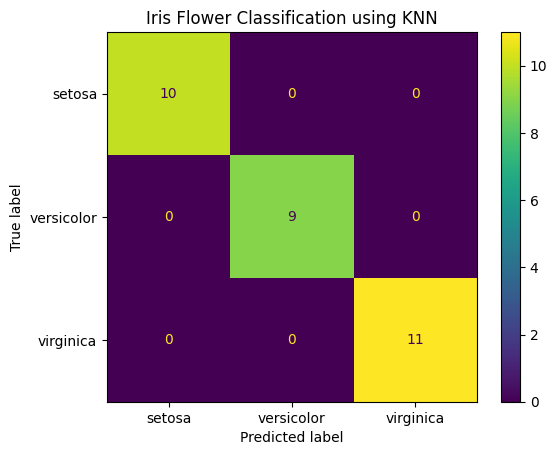


New Flower:
[[5.1 3.5 1.4 0.2]]

Predicted Flower Class:
setosa


In [13]:
# Experiment 12: Iris Flower Classification using KNN
# Aim: Implement K-Nearest Neighbours (KNN) algorithm
#      for Iris flower classification.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Iris Flower Dataset")
print("=" * 50)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nNumber of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split the dataset
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Calculate Euclidean Distance
# ---------------------------------------------------------

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


# ---------------------------------------------------------
# STEP 4: Implement KNN manually
# ---------------------------------------------------------

def knn_predict(X_train, y_train, X_test, k=5):

    predictions = []

    for test_sample in X_test:

        distances = []

        # Calculate distance from test sample
        # to every training sample
        for i, train_sample in enumerate(X_train):

            distance = euclidean_distance(
                test_sample,
                train_sample
            )

            distances.append((distance, y_train[i]))

        # Sort according to distance
        distances.sort(key=lambda x: x[0])

        # Select K nearest neighbours
        nearest_neighbors = distances[:k]

        # Get their class labels
        labels = [
            neighbor[1]
            for neighbor in nearest_neighbors
        ]

        # Majority voting
        prediction = max(
            set(labels),
            key=labels.count
        )

        predictions.append(prediction)

    return np.array(predictions)


# ---------------------------------------------------------
# STEP 5: Set K value
# ---------------------------------------------------------

k = 5

print("\nK value:", k)


# ---------------------------------------------------------
# STEP 6: Predict test samples
# ---------------------------------------------------------

y_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    k
)


# ---------------------------------------------------------
# STEP 7: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("KNN CLASSIFICATION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 8: Display actual vs predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):

    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 9: Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# Display confusion matrix graphically
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Iris Flower Classification using KNN")
plt.show()


# ---------------------------------------------------------
# STEP 10: Classify a new flower
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_prediction = knn_predict(
    X_train,
    y_train,
    new_flower,
    k
)

print("\nNew Flower:")
print(new_flower)

print("\nPredicted Flower Class:")
print(iris.target_names[new_prediction[0]])

Car Price Dataset
    Year  Kilometers_Driven  Engine_CC  Price_Lakh
0   2015              80000       1000         3.2
1   2016              75000       1200         3.5
2   2017              65000       1200         4.2
3   2018              55000       1500         5.0
4   2019              45000       1500         6.0
5   2020              35000       1600         7.0
6   2021              25000       1600         8.0
7   2022              15000       1800        10.0
8   2017              70000       1200         4.0
9   2019              40000       1500         6.5
10  2016              85000       1000         3.0
11  2018              60000       1400         5.2
12  2020              30000       1600         7.5
13  2021              20000       1800         9.0
14  2015              90000       1000         2.8
15  2022              10000       2000        11.0
16  2019              50000       1500         6.2
17  2017              72000       1200         4.0
18  2020     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


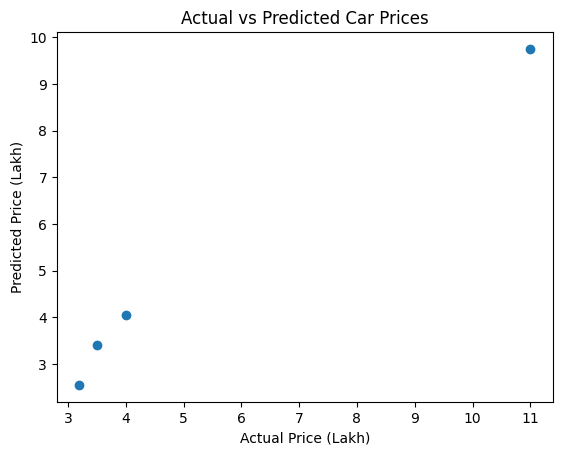

In [14]:
# Car Price Prediction Model using Python
# Aim: Predict the price of a car using Linear Regression.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create a basic car dataset
# ---------------------------------------------------------

data = {
    'Year': [
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2017, 2019,
        2016, 2018, 2020, 2021, 2015,
        2022, 2019, 2017, 2020, 2021
    ],

    'Kilometers_Driven': [
        80000, 75000, 65000, 55000, 45000,
        35000, 25000, 15000, 70000, 40000,
        85000, 60000, 30000, 20000, 90000,
        10000, 50000, 72000, 28000, 18000
    ],

    'Engine_CC': [
        1000, 1200, 1200, 1500, 1500,
        1600, 1600, 1800, 1200, 1500,
        1000, 1400, 1600, 1800, 1000,
        2000, 1500, 1200, 1600, 1800
    ],

    'Price_Lakh': [
        3.2, 3.5, 4.2, 5.0, 6.0,
        7.0, 8.0, 10.0, 4.0, 6.5,
        3.0, 5.2, 7.5, 9.0, 2.8,
        11.0, 6.2, 4.0, 7.8, 9.2
    ]
}

df = pd.DataFrame(data)

print("Car Price Dataset")
print("=" * 50)
print(df)


# ---------------------------------------------------------
# STEP 2: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Year', 'Kilometers_Driven', 'Engine_CC']
]

y = df['Price_Lakh']


# ---------------------------------------------------------
# STEP 3: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Linear Regression model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 5: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 6: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Display model results
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("CAR PRICE PREDICTION RESULTS")
print("=" * 50)

print("\nActual vs Predicted Price:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual: ₹",
        round(actual, 2),
        "Lakh\tPredicted: ₹",
        round(predicted, 2),
        "Lakh"
    )


# ---------------------------------------------------------
# STEP 8: Calculate performance
# ---------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):",
      round(mse, 4))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 9: Display coefficients
# ---------------------------------------------------------

print("\nModel Coefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        feature,
        ":",
        round(coefficient, 4)
    )

print("\nIntercept:",
      round(model.intercept_, 4))


# ---------------------------------------------------------
# STEP 10: Predict price of a new car
# ---------------------------------------------------------

new_car = np.array([
    [2021, 30000, 1500]
])

predicted_price = model.predict(new_car)

print("\n" + "=" * 50)
print("NEW CAR PRICE PREDICTION")
print("=" * 50)

print("\nCar Details:")
print("Year: 2021")
print("Kilometers Driven: 30,000")
print("Engine: 1500 CC")

print(
    "\nPredicted Price: ₹",
    round(predicted_price[0], 2),
    "Lakh"
)


# ---------------------------------------------------------
# STEP 11: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Actual vs Predicted Car Prices")

plt.show()

House Price Dataset
    Area_sqft  Bedrooms  Bathrooms  House_Age  Price_Lakh
0         800         2          1         20          25
1         900         2          1         18          28
2        1000         2          2         15          32
3        1100         2          2         14          35
4        1200         3          2         12          40
5        1300         3          2         10          44
6        1400         3          2          9          48
7        1500         3          2          8          52
8        1600         3          2          7          56
9        1700         3          3          6          61
10       1800         3          3          5          65
11       1900         3          3          5          70
12       2000         4          3          4          76
13       2200         4          3          4          84
14       2400         4          3          3          92
15       2500         4          3          3       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


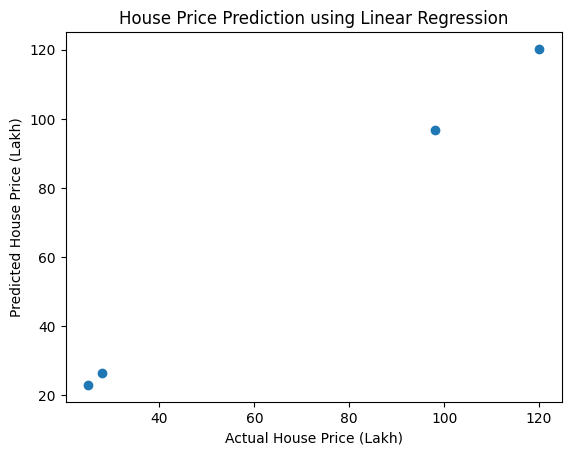

In [15]:
# House Price Prediction using Linear Regression
# Aim: Predict house prices using an appropriate
#      machine learning algorithm.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create a basic house price dataset
# ---------------------------------------------------------

data = {
    'Area_sqft': [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2200, 2400,
        2500, 2700, 3000, 3200, 3500
    ],

    'Bedrooms': [
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 5, 5
    ],

    'Bathrooms': [
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 4, 4, 4, 5
    ],

    'House_Age': [
        20, 18, 15, 14, 12,
        10, 9, 8, 7, 6,
        5, 5, 4, 4, 3,
        3, 2, 2, 1, 1
    ],

    'Price_Lakh': [
        25, 28, 32, 35, 40,
        44, 48, 52, 56, 61,
        65, 70, 76, 84, 92,
        98, 108, 120, 130, 145
    ]
}

df = pd.DataFrame(data)

print("House Price Dataset")
print("=" * 50)
print(df)


# ---------------------------------------------------------
# STEP 2: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age']
]

y = df['Price_Lakh']


# ---------------------------------------------------------
# STEP 3: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Linear Regression model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 5: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 6: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Display actual vs predicted prices
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("HOUSE PRICE PREDICTION RESULTS")
print("=" * 50)

print("\nActual vs Predicted Price:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual: ₹",
        round(actual, 2),
        "Lakh\tPredicted: ₹",
        round(predicted, 2),
        "Lakh"
    )


# ---------------------------------------------------------
# STEP 8: Calculate model performance
# ---------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):",
      round(mse, 4))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 9: Display model coefficients
# ---------------------------------------------------------

print("\nModel Coefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        feature,
        ":",
        round(coefficient, 4)
    )

print("\nIntercept:",
      round(model.intercept_, 4))


# ---------------------------------------------------------
# STEP 10: Predict price of a new house
# ---------------------------------------------------------

new_house = np.array([
    [1800, 3, 3, 5]
])

predicted_price = model.predict(new_house)

print("\n" + "=" * 50)
print("NEW HOUSE PRICE PREDICTION")
print("=" * 50)

print("\nHouse Details:")
print("Area: 1800 sq.ft")
print("Bedrooms: 3")
print("Bathrooms: 3")
print("House Age: 5 years")

print(
    "\nPredicted House Price: ₹",
    round(predicted_price[0], 2),
    "Lakh"
)


# ---------------------------------------------------------
# STEP 11: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual House Price (Lakh)")
plt.ylabel("Predicted House Price (Lakh)")
plt.title("House Price Prediction using Linear Regression")

plt.show()

IRIS FLOWER DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Total number of samples: 150

Training samples: 120
Testing samples: 30

NAÏVE BAYES CLASSIFICATION RESULTS

Accuracy: 100.0 %

Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: v

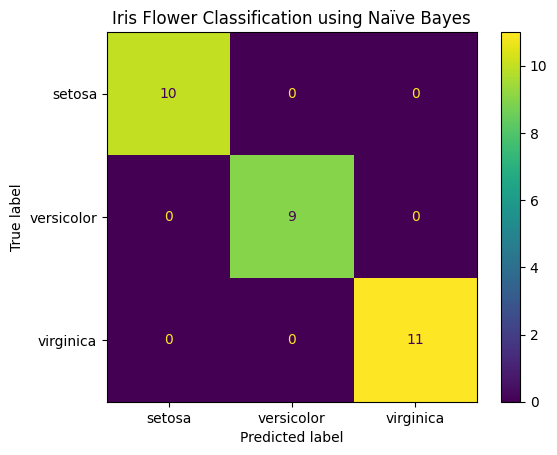


New Flower Details:
Sepal Length: 5.1 cm
Sepal Width: 3.5 cm
Petal Length: 1.4 cm
Petal Width: 0.2 cm

Predicted Flower Class:
setosa


In [16]:
# Experiment: Iris Flower Classification using Naïve Bayes
# Aim: Implement Iris flower classification using
#      the Naïve Bayes classifier.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("IRIS FLOWER DATASET")
print("=" * 50)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nTotal number of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Create Naïve Bayes classifier
# ---------------------------------------------------------

model = GaussianNB()


# ---------------------------------------------------------
# STEP 4: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 5: Predict the test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 6: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("NAÏVE BAYES CLASSIFICATION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 7: Display actual vs predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):

    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 8: Generate confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 9: Display confusion matrix graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Iris Flower Classification using Naïve Bayes")
plt.show()


# ---------------------------------------------------------
# STEP 10: Classify a new flower
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

prediction = model.predict(new_flower)

print("\nNew Flower Details:")
print("Sepal Length: 5.1 cm")
print("Sepal Width: 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width: 0.2 cm")

print("\nPredicted Flower Class:")
print(iris.target_names[prediction[0]])

IRIS FLOWER DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Total number of samples: 150

Training samples: 120
Testing samples: 30

CLASSIFICATION ALGORITHM PERFORMANCE

Algorithm: Logistic Regression
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %

Algorithm: K-Nearest Neighbors
Accuracy : 93.33 %
Precision: 94.44 %
Recall   : 93.33 %
F1-Score : 93.27 %

Algorithm: Decision Tree
Accuracy : 93.33 %
Precision: 93.33 %
Recall   : 93.33 %
F1-Score : 93.33 %

Algorithm: Naive Bayes
Accuracy : 96.67 %
Precision: 96.97 %
Recall   : 96.67 %
F1-Score : 96.66 %

Algorithm: Support Vector Machine
Accuracy : 96.67 %
Precision: 96.97 %
Recall   : 96.67 %
F1-Score : 96.66 %

Algorithm: Random Forest
Accuracy : 90.0 %
Precision: 90.24 %
Recall   : 90.0 %
F1-Score : 89.97 %

ALGORITHM PERFORMANCE COMPARISON

Algorithm                 Accuracy     Precision    Recall       

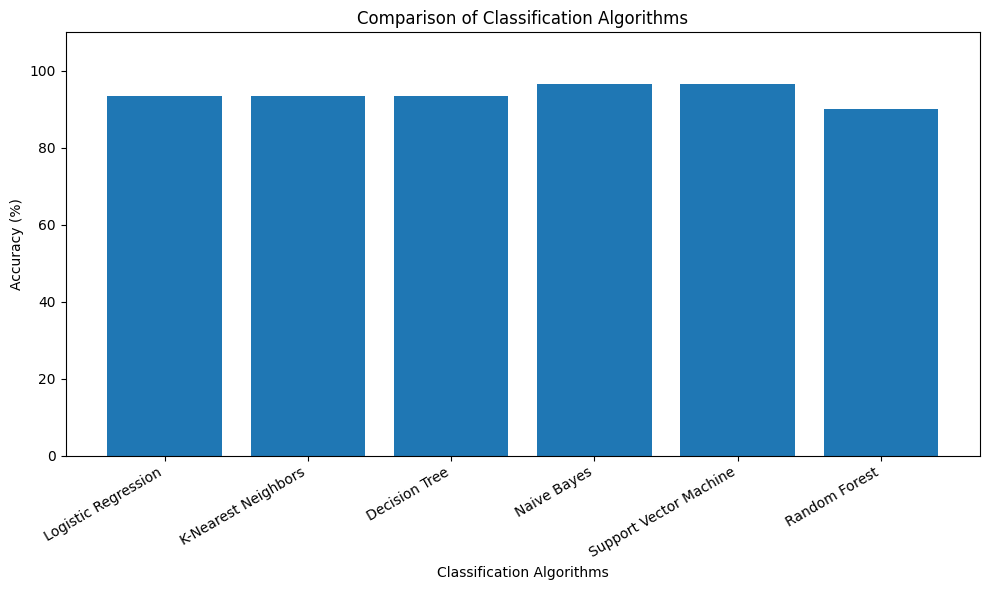

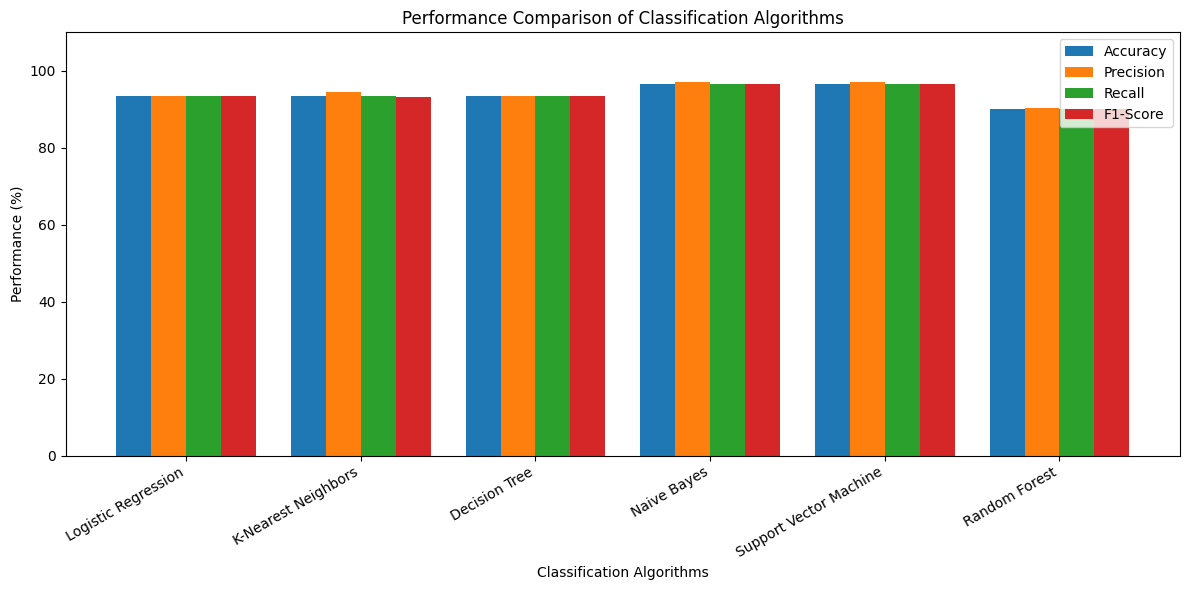


--------------------------------------------------
Confusion Matrix - Logistic Regression
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


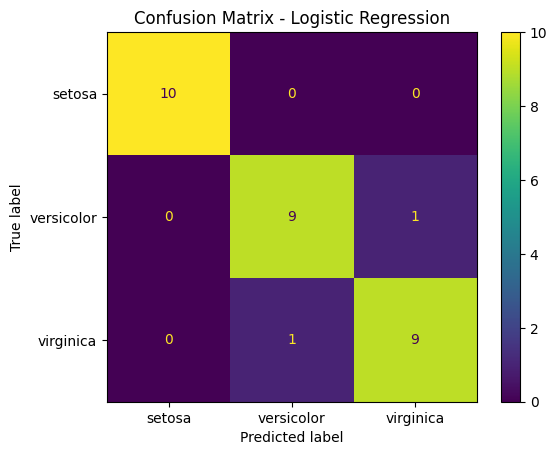


--------------------------------------------------
Confusion Matrix - K-Nearest Neighbors
--------------------------------------------------
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


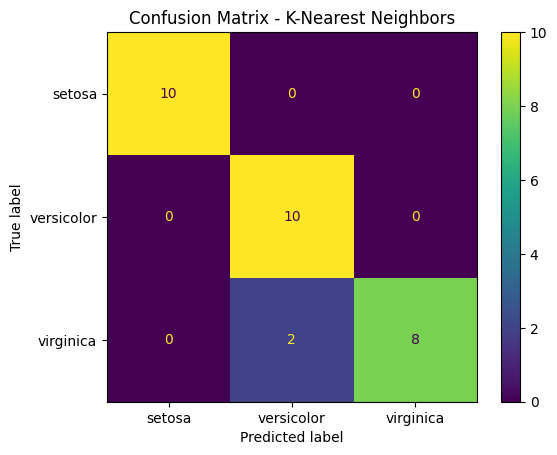


--------------------------------------------------
Confusion Matrix - Decision Tree
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


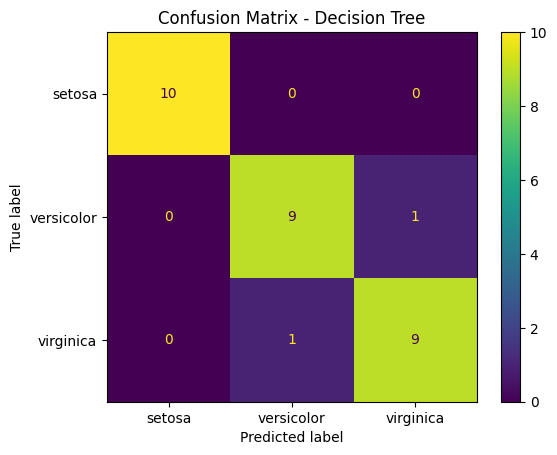


--------------------------------------------------
Confusion Matrix - Naive Bayes
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


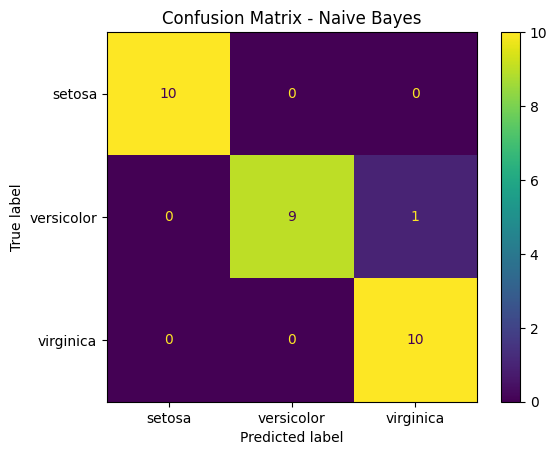


--------------------------------------------------
Confusion Matrix - Support Vector Machine
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


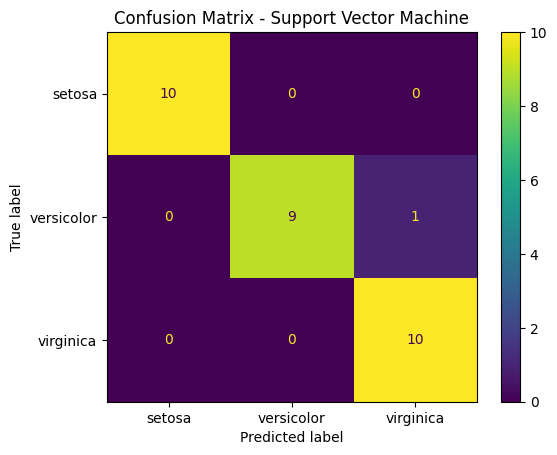


--------------------------------------------------
Confusion Matrix - Random Forest
--------------------------------------------------
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


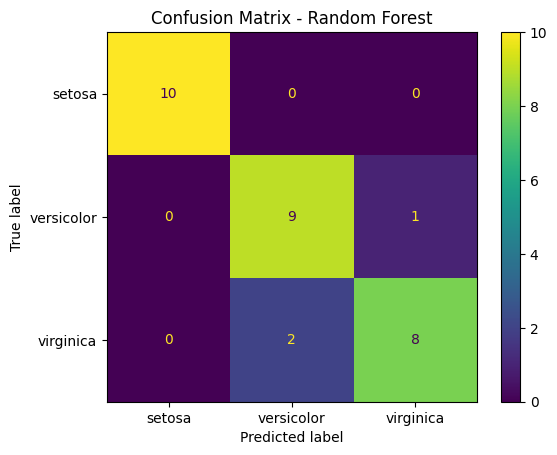


NEW FLOWER CLASSIFICATION

New Flower Details:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm

Best Algorithm: Naive Bayes
Predicted Flower Class: setosa


In [17]:
# Experiment: Comparison of Classification Algorithms
# Aim: Compare different classification algorithms and
#      evaluate their performance.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("IRIS FLOWER DATASET")
print("=" * 60)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nTotal number of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ---------------------------------------------------------
# STEP 4: Create classification models
# ---------------------------------------------------------

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=200),

    "K-Nearest Neighbors":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "Support Vector Machine":
        SVC(),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}


# ---------------------------------------------------------
# STEP 5: Train and evaluate each model
# ---------------------------------------------------------

results = {}

print("\n" + "=" * 60)
print("CLASSIFICATION ALGORITHM PERFORMANCE")
print("=" * 60)

for name, model in models.items():

    # Use scaled data for Logistic Regression, KNN and SVM
    if name in [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)


    # Calculate performance metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


    print("\nAlgorithm:", name)

    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1-Score :", round(f1 * 100, 2), "%")


# ---------------------------------------------------------
# STEP 6: Display comparison table
# ---------------------------------------------------------

print("\n" + "=" * 80)
print("ALGORITHM PERFORMANCE COMPARISON")
print("=" * 80)

print(
    "\n{:<25} {:<12} {:<12} {:<12} {:<12}".format(
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    )
)

print("-" * 80)

for name, metrics in results.items():

    print(
        "{:<25} {:<12.2f} {:<12.2f} {:<12.2f} {:<12.2f}".format(
            name,
            metrics["Accuracy"] * 100,
            metrics["Precision"] * 100,
            metrics["Recall"] * 100,
            metrics["F1-Score"] * 100
        )
    )


# ---------------------------------------------------------
# STEP 7: Find the best performing algorithm
# ---------------------------------------------------------

best_algorithm = max(
    results,
    key=lambda x: results[x]["Accuracy"]
)

best_accuracy = results[best_algorithm]["Accuracy"]

print("\n" + "=" * 60)
print("BEST PERFORMING ALGORITHM")
print("=" * 60)

print("\nAlgorithm:", best_algorithm)
print("Accuracy:", round(best_accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 8: Plot accuracy comparison
# ---------------------------------------------------------

algorithm_names = list(results.keys())

accuracy_values = [
    results[name]["Accuracy"] * 100
    for name in algorithm_names
]

plt.figure(figsize=(10, 6))

plt.bar(
    algorithm_names,
    accuracy_values
)

plt.xlabel("Classification Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Classification Algorithms")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 110)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 9: Plot all performance metrics
# ---------------------------------------------------------

precision_values = [
    results[name]["Precision"] * 100
    for name in algorithm_names
]

recall_values = [
    results[name]["Recall"] * 100
    for name in algorithm_names
]

f1_values = [
    results[name]["F1-Score"] * 100
    for name in algorithm_names
]

x = np.arange(len(algorithm_names))

width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x + width,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + 2 * width,
    f1_values,
    width,
    label="F1-Score"
)

plt.xlabel("Classification Algorithms")
plt.ylabel("Performance (%)")
plt.title("Performance Comparison of Classification Algorithms")

plt.xticks(
    x + width / 2,
    algorithm_names,
    rotation=30,
    ha="right"
)

plt.ylim(0, 110)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 10: Generate confusion matrices
# ---------------------------------------------------------

for name, model in models.items():

    if name in [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ]:

        y_pred = model.predict(X_test_scaled)

    else:

        y_pred = model.predict(X_test)


    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "-" * 50)
    print("Confusion Matrix -", name)
    print("-" * 50)

    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=iris.target_names
    )

    disp.plot()

    plt.title(
        "Confusion Matrix - " + name
    )

    plt.show()


# ---------------------------------------------------------
# STEP 11: Predict a new flower using the best algorithm
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])


# Train/predict using the best algorithm

best_model = models[best_algorithm]


if best_algorithm in [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine"
]:

    new_flower_scaled = scaler.transform(new_flower)

    prediction = best_model.predict(
        new_flower_scaled
    )

else:

    prediction = best_model.predict(
        new_flower
    )


print("\n" + "=" * 60)
print("NEW FLOWER CLASSIFICATION")
print("=" * 60)

print("\nNew Flower Details:")

print("Sepal Length: 5.1 cm")
print("Sepal Width : 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width : 0.2 cm")

print("\nBest Algorithm:", best_algorithm)

print(
    "Predicted Flower Class:",
    iris.target_names[prediction[0]]
)

MOBILE PRICE DATASET

Dataset:
    RAM  Storage  Battery  Camera  ScreenSize  Price
0     2       32     3000       8         5.0   7000
1     3       32     3500      12         5.5   9000
2     4       64     4000      16         6.0  12000
3     4      128     4500      16         6.1  15000
4     6      128     4500      32         6.2  18000
5     6      256     5000      48         6.4  22000
6     8      128     4500      48         6.5  25000
7     8      256     5000      64         6.6  30000
8    12      256     5000      64         6.7  40000
9    12      512     5500     108         6.7  50000
10   16      512     5500     108         6.8  65000
11   16     1024     6000     200         6.9  85000

Number of samples: 12

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   RAM         12 non-null     int64  
 1   Stora

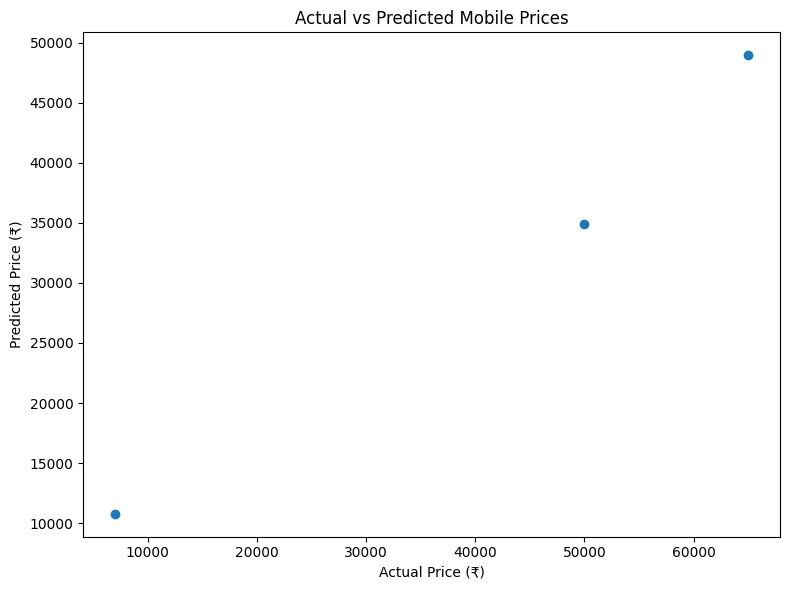

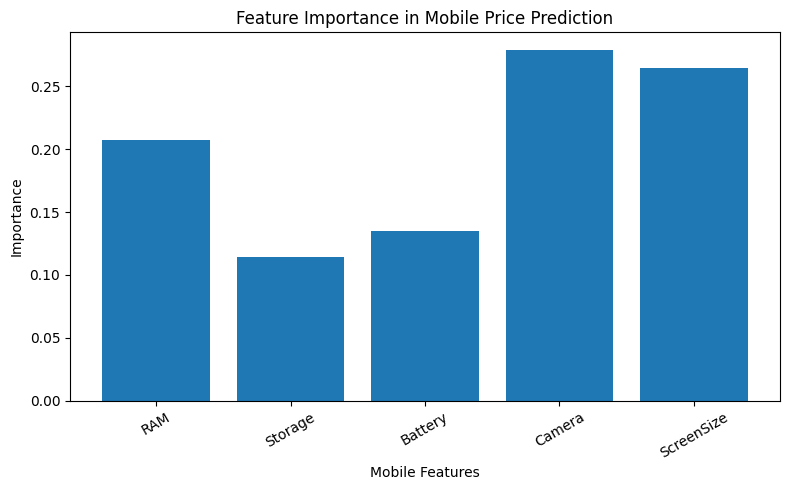


NEW MOBILE PRICE PREDICTION

Mobile Specifications:
RAM        : 8 GB
Storage    : 256 GB
Battery    : 5000 mAh
Camera     : 64 MP
Screen Size: 6.6 inches

Predicted Mobile Price: ₹ 29770.0


In [18]:
# Experiment: Mobile Price Prediction using Random Forest Regression
# Aim: Implement a Mobile Price Prediction model using
#      an appropriate machine learning algorithm.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------------------------
# STEP 1: Create Mobile Price Dataset
# ---------------------------------------------------------

data = {
    "RAM": [2, 3, 4, 4, 6, 6, 8, 8, 12, 12, 16, 16],
    "Storage": [32, 32, 64, 128, 128, 256, 128, 256, 256, 512, 512, 1024],
    "Battery": [3000, 3500, 4000, 4500, 4500, 5000,
                4500, 5000, 5000, 5500, 5500, 6000],
    "Camera": [8, 12, 16, 16, 32, 48, 48, 64, 64, 108, 108, 200],
    "ScreenSize": [5.0, 5.5, 6.0, 6.1, 6.2, 6.4,
                   6.5, 6.6, 6.7, 6.7, 6.8, 6.9],
    "Price": [7000, 9000, 12000, 15000, 18000, 22000,
              25000, 30000, 40000, 50000, 65000, 85000]
}

df = pd.DataFrame(data)

print("MOBILE PRICE DATASET")
print("=" * 60)

print("\nDataset:")
print(df)

print("\nNumber of samples:", len(df))

print("\nDataset Information:")
print(df.info())


# ---------------------------------------------------------
# STEP 2: Separate Features and Target
# ---------------------------------------------------------

X = df.drop("Price", axis=1)

y = df["Price"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Variable: Price")


# ---------------------------------------------------------
# STEP 3: Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Random Forest Regression Model
# ---------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# ---------------------------------------------------------
# STEP 5: Train the Model
# ---------------------------------------------------------

model.fit(X_train, y_train)

print("\nRandom Forest Regression Model Trained Successfully!")


# ---------------------------------------------------------
# STEP 6: Predict Mobile Prices
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Evaluate Model Performance
# ---------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\n" + "=" * 60)
print("MOBILE PRICE PREDICTION RESULTS")
print("=" * 60)

print("\nMean Absolute Error (MAE):",
      round(mae, 2))

print("Mean Squared Error (MSE):",
      round(mse, 2))

print("Root Mean Squared Error (RMSE):",
      round(rmse, 2))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 8: Display Actual vs Predicted Prices
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED PRICES")
print("=" * 60)

for actual, predicted in zip(y_test, y_pred):

    print(
        "Actual Price: ₹",
        round(actual, 2),
        "\tPredicted Price: ₹",
        round(predicted, 2)
    )


# ---------------------------------------------------------
# STEP 9: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")

plt.title(
    "Actual vs Predicted Mobile Prices"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 10: Feature Importance
# ---------------------------------------------------------

feature_importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(
    X.columns,
    feature_importance
)

plt.xlabel("Mobile Features")
plt.ylabel("Importance")

plt.title(
    "Feature Importance in Mobile Price Prediction"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 11: Predict Price of a New Mobile
# ---------------------------------------------------------

new_mobile = pd.DataFrame({
    "RAM": [8],
    "Storage": [256],
    "Battery": [5000],
    "Camera": [64],
    "ScreenSize": [6.6]
})


predicted_price = model.predict(new_mobile)


print("\n" + "=" * 60)
print("NEW MOBILE PRICE PREDICTION")
print("=" * 60)

print("\nMobile Specifications:")

print("RAM        :", new_mobile["RAM"].iloc[0], "GB")
print("Storage    :", new_mobile["Storage"].iloc[0], "GB")
print("Battery    :", new_mobile["Battery"].iloc[0], "mAh")
print("Camera     :", new_mobile["Camera"].iloc[0], "MP")
print("Screen Size:", new_mobile["ScreenSize"].iloc[0], "inches")

print(
    "\nPredicted Mobile Price: ₹",
    round(predicted_price[0], 2)
)

IRIS FLOWER DATASET

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Total number of samples: 150

Training samples: 120
Testing samples: 30

Feature scaling completed.

Perceptron model trained successfully!

PERCEPTRON IRIS CLASSIFICATION RESULTS

Accuracy: 90.0 %

Actual vs Predicted:
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: virginica 	Predicted: virginica
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual

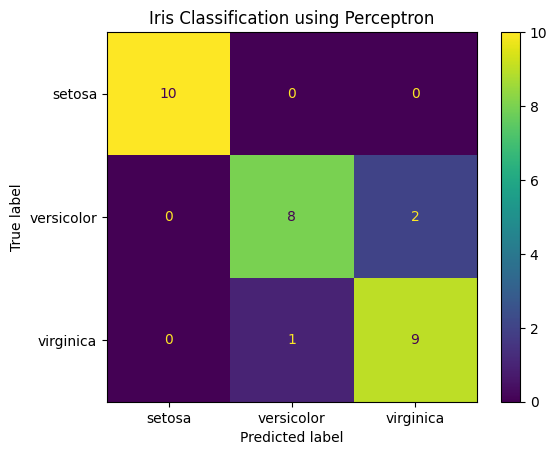


NEW FLOWER CLASSIFICATION

New Flower Details:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm

Predicted Flower Class:
setosa


In [19]:
# Experiment: Perceptron Based Iris Classification
# Aim: Implement Iris flower classification using
#      the Perceptron algorithm.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("IRIS FLOWER DATASET")
print("=" * 60)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nTotal number of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ---------------------------------------------------------
# STEP 4: Create Perceptron classifier
# ---------------------------------------------------------

model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)


# ---------------------------------------------------------
# STEP 5: Train the Perceptron model
# ---------------------------------------------------------

model.fit(
    X_train_scaled,
    y_train
)

print("\nPerceptron model trained successfully!")


# ---------------------------------------------------------
# STEP 6: Predict the test data
# ---------------------------------------------------------

y_pred = model.predict(
    X_test_scaled
)


# ---------------------------------------------------------
# STEP 7: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("PERCEPTRON IRIS CLASSIFICATION RESULTS")
print("=" * 60)

print("\nAccuracy:",
      round(accuracy * 100, 2),
      "%")


# ---------------------------------------------------------
# STEP 8: Display actual vs predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(
    y_test,
    y_pred
):

    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 9: Classification Report
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# ---------------------------------------------------------
# STEP 10: Generate confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 11: Display confusion matrix graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title(
    "Iris Classification using Perceptron"
)

plt.show()


# ---------------------------------------------------------
# STEP 12: Classify a new flower
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])


# Scale the new flower using
# the same scaler used for training

new_flower_scaled = scaler.transform(
    new_flower
)


prediction = model.predict(
    new_flower_scaled
)


print("\n" + "=" * 60)
print("NEW FLOWER CLASSIFICATION")
print("=" * 60)

print("\nNew Flower Details:")

print("Sepal Length: 5.1 cm")
print("Sepal Width : 3.5 cm")
print("Petal Length: 1.4 cm")
print("Petal Width : 0.2 cm")

print("\nPredicted Flower Class:")

print(
    iris.target_names[prediction[0]]
)

BANK LOAN DATASET

Dataset:
    Gender Married     Education  ApplicantIncome  LoanAmount  CreditHistory  \
0     Male     Yes      Graduate             5000         150              1   
1   Female      No      Graduate             3000         100              1   
2     Male     Yes  Not Graduate             2500          80              0   
3     Male     Yes      Graduate             6000         200              1   
4   Female      No      Graduate             4000         120              1   
5     Male     Yes  Not Graduate             3500         100              0   
6   Female     Yes      Graduate             7000         250              1   
7     Male      No      Graduate             4500         150              1   
8   Female      No  Not Graduate             2800          90              0   
9     Male     Yes      Graduate             8000         300              1   
10    Male     Yes      Graduate             5500         180              1   
11  Female  

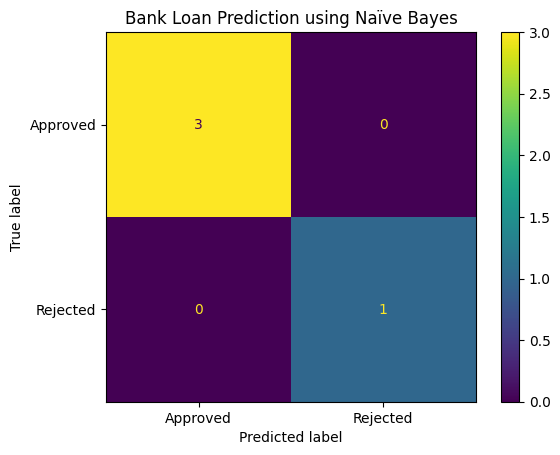


NEW LOAN APPLICATION PREDICTION

Applicant Details:
Gender          : Male
Married         : Yes
Education       : Graduate
Applicant Income: ₹6000
Loan Amount     : ₹180,000
Credit History  : Good

Predicted Loan Status:
LOAN APPROVED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [20]:
# Experiment: Bank Loan Prediction using Naïve Bayes
# Aim: Implement Naïve Bayes classification for
#      Bank Loan Prediction.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ---------------------------------------------------------
# STEP 1: Create Bank Loan Dataset
# ---------------------------------------------------------

data = {
    "Gender": [
        "Male", "Female", "Male", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],

    "Married": [
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "No", "Yes",
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "Education": [
        "Graduate", "Graduate", "Not Graduate", "Graduate", "Graduate",
        "Not Graduate", "Graduate", "Graduate", "Not Graduate", "Graduate",
        "Graduate", "Graduate", "Not Graduate", "Graduate", "Graduate",
        "Not Graduate", "Graduate", "Graduate", "Not Graduate", "Graduate"
    ],

    "ApplicantIncome": [
        5000, 3000, 2500, 6000, 4000,
        3500, 7000, 4500, 2800, 8000,
        5500, 3200, 2700, 6500, 9000,
        3000, 7500, 5000, 2200, 6000
    ],

    "LoanAmount": [
        150, 100, 80, 200, 120,
        100, 250, 150, 90, 300,
        180, 110, 85, 200, 350,
        100, 280, 170, 70, 220
    ],

    "CreditHistory": [
        1, 1, 0, 1, 1,
        0, 1, 1, 0, 1,
        1, 0, 1, 1, 1,
        0, 1, 1, 0, 1
    ],

    "Loan_Status": [
        "Approved", "Approved", "Rejected", "Approved", "Approved",
        "Rejected", "Approved", "Approved", "Rejected", "Approved",
        "Approved", "Rejected", "Approved", "Approved", "Approved",
        "Rejected", "Approved", "Approved", "Rejected", "Approved"
    ]
}


df = pd.DataFrame(data)


print("BANK LOAN DATASET")
print("=" * 60)

print("\nDataset:")
print(df)

print("\nTotal number of samples:",
      len(df))


# ---------------------------------------------------------
# STEP 2: Encode Categorical Features
# ---------------------------------------------------------

label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(
    df["Gender"]
)

df["Married"] = label_encoder.fit_transform(
    df["Married"]
)

df["Education"] = label_encoder.fit_transform(
    df["Education"]
)

df["Loan_Status"] = label_encoder.fit_transform(
    df["Loan_Status"]
)


print("\nEncoded Dataset:")
print(df)


# ---------------------------------------------------------
# STEP 3: Separate Features and Target
# ---------------------------------------------------------

X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget: Loan Status")


# ---------------------------------------------------------
# STEP 4: Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining samples:",
      len(X_train))

print("Testing samples:",
      len(X_test))


# ---------------------------------------------------------
# STEP 5: Create Naïve Bayes Classifier
# ---------------------------------------------------------

model = GaussianNB()


# ---------------------------------------------------------
# STEP 6: Train the Model
# ---------------------------------------------------------

model.fit(
    X_train,
    y_train
)


print("\nNaïve Bayes model trained successfully!")


# ---------------------------------------------------------
# STEP 7: Predict Test Data
# ---------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ---------------------------------------------------------
# STEP 8: Calculate Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("NAÏVE BAYES BANK LOAN PREDICTION RESULTS")
print("=" * 60)

print("\nAccuracy:",
      round(accuracy * 100, 2),
      "%")


# ---------------------------------------------------------
# STEP 9: Display Actual vs Predicted Results
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(
    y_test,
    y_pred
):

    actual_status = (
        "Approved"
        if actual == 0
        else "Rejected"
    )

    predicted_status = (
        "Approved"
        if predicted == 0
        else "Rejected"
    )

    print(
        "Actual:",
        actual_status,
        "\tPredicted:",
        predicted_status
    )


# ---------------------------------------------------------
# STEP 10: Classification Report
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Approved",
            "Rejected"
        ]
    )
)


# ---------------------------------------------------------
# STEP 11: Generate Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ---------------------------------------------------------
# STEP 12: Display Confusion Matrix Graphically
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Approved",
        "Rejected"
    ]
)

disp.plot()

plt.title(
    "Bank Loan Prediction using Naïve Bayes"
)

plt.show()


# ---------------------------------------------------------
# STEP 13: Predict a New Loan Application
# ---------------------------------------------------------

# Gender:
# Male = 1, Female = 0
#
# Married:
# Yes = 1, No = 0
#
# Education:
# Graduate = 0, Not Graduate = 1
#
# CreditHistory:
# 1 = Good, 0 = Poor


new_applicant = np.array([
    [1, 1, 0, 6000, 180, 1]
])


prediction = model.predict(
    new_applicant
)


print("\n" + "=" * 60)
print("NEW LOAN APPLICATION PREDICTION")
print("=" * 60)

print("\nApplicant Details:")

print("Gender          : Male")
print("Married         : Yes")
print("Education       : Graduate")
print("Applicant Income: ₹6000")
print("Loan Amount     : ₹180,000")
print("Credit History  : Good")


print("\nPredicted Loan Status:")

if prediction[0] == 0:

    print("LOAN APPROVED")

else:

    print("LOAN REJECTED")

FUTURE SALES PREDICTION DATASET

Dataset:
    Month  Sales
0       1    120
1       2    135
2       3    150
3       4    160
4       5    175
5       6    190
6       7    205
7       8    220
8       9    235
9      10    250
10     11    265
11     12    280
12     13    295
13     14    310
14     15    325
15     16    340
16     17    355
17     18    370
18     19    385
19     20    400
20     21    415
21     22    430
22     23    445
23     24    460

Total number of samples: 24

Feature:
Month

Target:
Sales

Training samples: 19
Testing samples: 5

Linear Regression model trained successfully!

FUTURE SALES PREDICTION RESULTS

Mean Absolute Error (MAE): 0.99
Mean Squared Error (MSE): 2.3
Root Mean Squared Error (RMSE): 1.52
R² Score: 0.9997

ACTUAL VS PREDICTED SALES
Actual Sales: 235 	Predicted Sales: 235.93
Actual Sales: 355 	Predicted Sales: 355.06
Actual Sales: 120 	Predicted Sales: 116.8
Actual Sales: 385 	Predicted Sales: 384.85
Actual Sales: 280 	Predicted Sales: 2

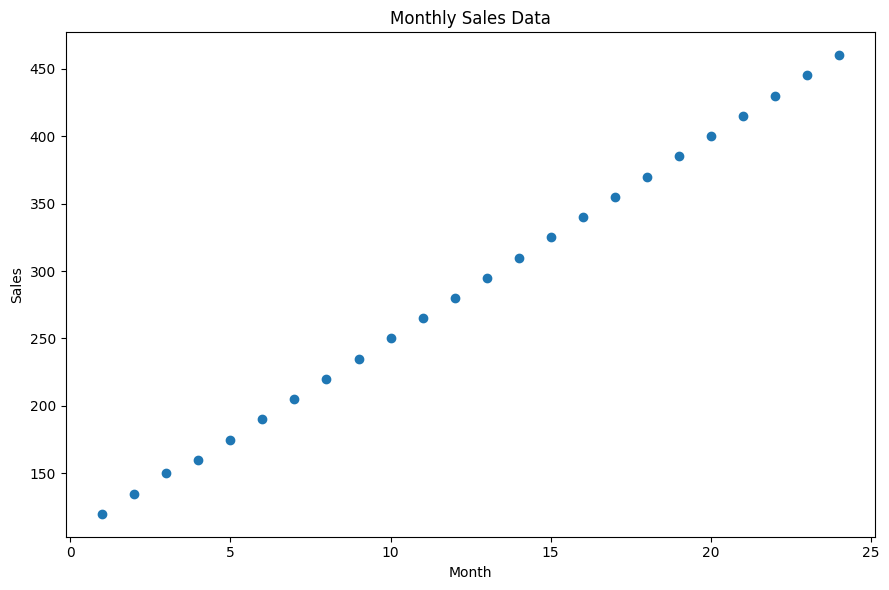

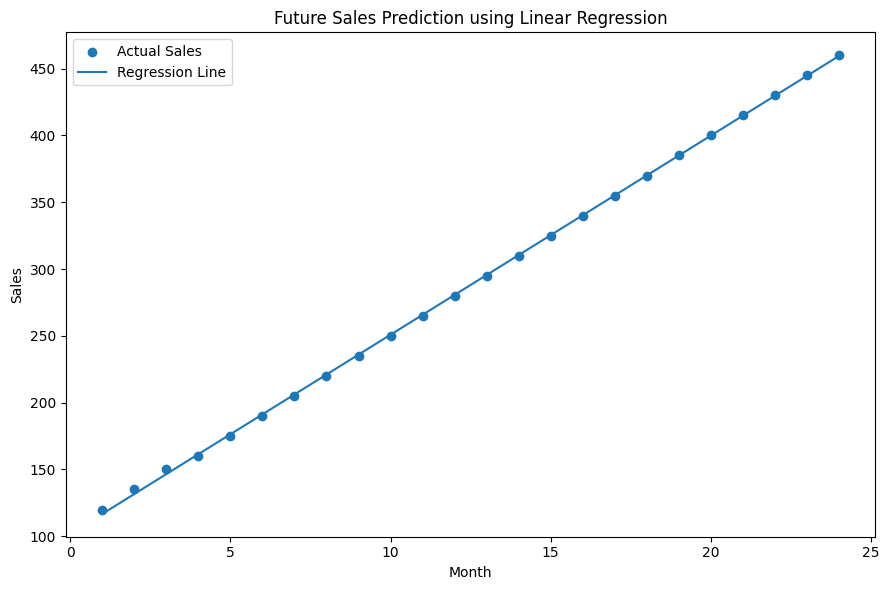

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



FUTURE SALES PREDICTION
Month 25 -> Predicted Sales: 474.19
Month 26 -> Predicted Sales: 489.08
Month 27 -> Predicted Sales: 503.98
Month 28 -> Predicted Sales: 518.87
Month 29 -> Predicted Sales: 533.76
Month 30 -> Predicted Sales: 548.65

LINEAR REGRESSION EQUATION

Sales = 14.89 * Month + 101.91


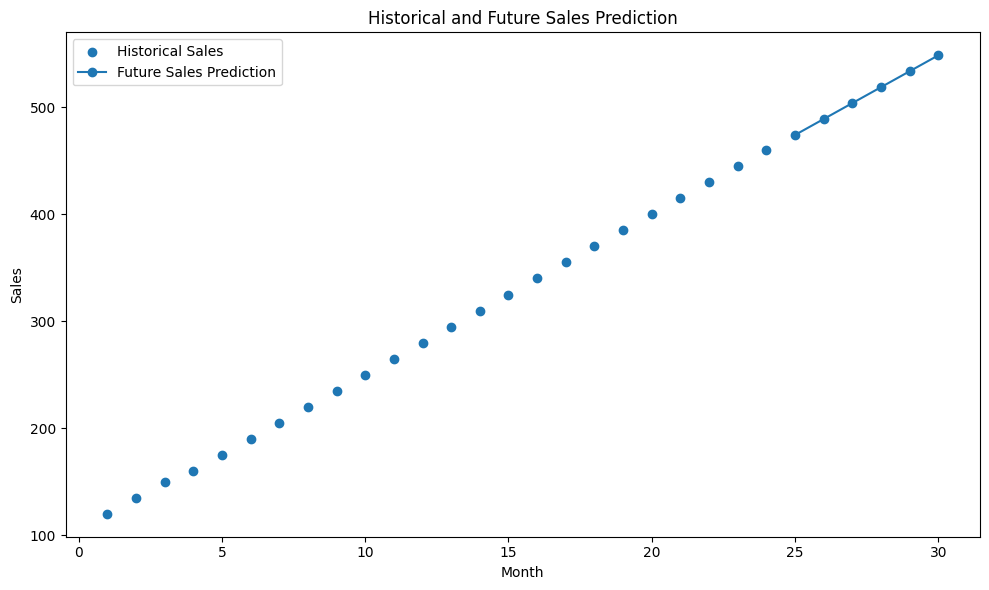

In [21]:
# Experiment: Future Sales Prediction using Linear Regression
# Aim: Implement Future Sales Prediction using
#      a suitable machine learning algorithm.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------------------------
# STEP 1: Create Sales Dataset
# ---------------------------------------------------------

data = {
    "Month": [
        1, 2, 3, 4, 5, 6,
        7, 8, 9, 10, 11, 12,
        13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24
    ],

    "Sales": [
        120, 135, 150, 160, 175, 190,
        205, 220, 235, 250, 265, 280,
        295, 310, 325, 340, 355, 370,
        385, 400, 415, 430, 445, 460
    ]
}


df = pd.DataFrame(data)


print("FUTURE SALES PREDICTION DATASET")
print("=" * 60)

print("\nDataset:")
print(df)

print("\nTotal number of samples:",
      len(df))


# ---------------------------------------------------------
# STEP 2: Separate Features and Target
# ---------------------------------------------------------

X = df[["Month"]]

y = df["Sales"]


print("\nFeature:")
print("Month")

print("\nTarget:")
print("Sales")


# ---------------------------------------------------------
# STEP 3: Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining samples:",
      len(X_train))

print("Testing samples:",
      len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Linear Regression Model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 5: Train the Model
# ---------------------------------------------------------

model.fit(
    X_train,
    y_train
)


print("\nLinear Regression model trained successfully!")


# ---------------------------------------------------------
# STEP 6: Predict Test Data
# ---------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ---------------------------------------------------------
# STEP 7: Evaluate Model Performance
# ---------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n" + "=" * 60)
print("FUTURE SALES PREDICTION RESULTS")
print("=" * 60)

print("\nMean Absolute Error (MAE):",
      round(mae, 2))

print("Mean Squared Error (MSE):",
      round(mse, 2))

print("Root Mean Squared Error (RMSE):",
      round(rmse, 2))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 8: Display Actual vs Predicted Sales
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ACTUAL VS PREDICTED SALES")
print("=" * 60)

for actual, predicted in zip(
    y_test,
    y_pred
):

    print(
        "Actual Sales:",
        round(actual, 2),
        "\tPredicted Sales:",
        round(predicted, 2)
    )


# ---------------------------------------------------------
# STEP 9: Plot Actual Sales Data
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title(
    "Monthly Sales Data"
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 10: Plot Regression Line
# ---------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    label="Actual Sales"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title(
    "Future Sales Prediction using Linear Regression"
)

plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# STEP 11: Predict Future Sales
# ---------------------------------------------------------

future_months = np.array([
    [25],
    [26],
    [27],
    [28],
    [29],
    [30]
])


future_sales = model.predict(
    future_months
)


print("\n" + "=" * 60)
print("FUTURE SALES PREDICTION")
print("=" * 60)

for month, sales in zip(
    future_months.flatten(),
    future_sales
):

    print(
        "Month",
        month,
        "-> Predicted Sales:",
        round(sales, 2)
    )


# ---------------------------------------------------------
# STEP 12: Display Regression Equation
# ---------------------------------------------------------

slope = model.coef_[0]

intercept = model.intercept_


print("\n" + "=" * 60)
print("LINEAR REGRESSION EQUATION")
print("=" * 60)

print(
    "\nSales =",
    round(slope, 2),
    "* Month +",
    round(intercept, 2)
)


# ---------------------------------------------------------
# STEP 13: Plot Future Sales Prediction
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Month"],
    df["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_months,
    future_sales,
    marker="o",
    label="Future Sales Prediction"
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title(
    "Historical and Future Sales Prediction"
)

plt.legend()

plt.tight_layout()

plt.show()